In [1]:
#Importing necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score)
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
df = pd.read_excel('../Data/final_feature_engineered_data.xlsx')


In [3]:
# FEATURE CORRELATION WITH TARGET

numeric_df = df.select_dtypes(include=['int64', 'float64'])

target_corr = (
    numeric_df.corr()['Payment_Next30Days']
    .sort_values(ascending=False)
)

display(target_corr)

Payment_Next30Days         1.000000
payment_flag               0.984407
log_last_payment           0.951239
last_pmt_amt               0.321877
times_up                   0.294296
ptp_flag                   0.269952
times_ptp                  0.268516
times_rpc                  0.092420
connect_rate               0.088837
times_lm                   0.085142
status                     0.069748
total_portal_visit         0.061412
times_connect              0.059623
rpc_rate                   0.056139
portal_engaged             0.044765
contact_efficiency         0.038814
times_contact              0.031237
customer_age               0.019209
total_comm_events          0.010270
unique_event_types         0.010125
days_since_last_comm       0.000056
original_balance          -0.001791
times_drop                -0.007222
current_balance           -0.010777
times_dials               -0.016018
log_times_dials           -0.020907
balance_ratio             -0.365357
days_since_last_payment   -0

In [4]:
# FEATURE - TARGET SEPARATION
leakage_proxy_cols = [
    'clnt_no',
    'payment_flag',
    'log_last_payment',
    'last_pmt_amt',
    'days_since_last_payment',
    'ptp_flag',
    'times_ptp',
    
]

X = df.drop(columns=leakage_proxy_cols + ['Payment_Next30Days'])
y = df['Payment_Next30Days']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (154765, 23)
Target Shape: (154765,)


In [5]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #Because target is highly imbalanced. This preserves class ratio in train/test sets.
)

print("X Train Shape:", X_train.shape)
print("X Test Shape:", X_test.shape)

print("\nTarget Distribution in Train:")
print(y_train.value_counts(normalize=True))

print("\nTarget Distribution in Test:")
print(y_test.value_counts(normalize=True))

X Train Shape: (123812, 23)
X Test Shape: (30953, 23)

Target Distribution in Train:
Payment_Next30Days
0    0.995937
1    0.004063
Name: proportion, dtype: float64

Target Distribution in Test:
Payment_Next30Days
0    0.995929
1    0.004071
Name: proportion, dtype: float64


In [6]:
# ENCODE CATEGORICAL FEATURES
categorical_cols = X_train.select_dtypes(include=['object']).columns

# One Hot Encoding

X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=True
)



print("Encoded X_train Shape:", X_train.shape)
print("Encoded X_test Shape:", X_test.shape)

Encoded X_train Shape: (123812, 302)
Encoded X_test Shape: (30953, 244)


In [7]:
# Align Train and Test Columns

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (123812, 302)
Test Shape: (30953, 302)


In [32]:
# BASELINE LOGISTIC REGRESSION MODEL


log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Prediction Probabilities
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [33]:
# LOGISTIC REGRESSION EVALUATION


print("Classification Report: Logisitic Regression\n")

print(classification_report(y_test, y_pred_log))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_log))

print("\nPR-AUC Score:")
print(average_precision_score(y_test, y_prob_log))

print("\nF1 Score:")
print(f1_score(y_test, y_pred_log))

Classification Report: Logisitic Regression

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30827
           1       0.74      0.28      0.40       126

    accuracy                           1.00     30953
   macro avg       0.87      0.64      0.70     30953
weighted avg       1.00      1.00      1.00     30953


ROC-AUC Score:
0.9430534251308248

PR-AUC Score:
0.43867195217088917

F1 Score:
0.4046242774566474


# Baseline Logistic Regression Results

| Metric | Value |
|---|---|
| Precision | 0.74 |
| Recall | 0.28 |
| F1 Score | 0.405 |
| ROC-AUC | 0.943 |
| PR-AUC | 0.439 |

---

# Interpretation

## What Went Well

- Strong ROC-AUC (~0.94)
- Good ranking capability
- High precision on positive class

---

## Limitations

- Low recall (0.28)
- Conservative positive predictions
- Misses many actual payers

In [ ]:
#   Model 2- Weighted Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Prediction probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [35]:
# RANDOM FOREST EVALUATION

print("Classification Report: Random Forest\n")

print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_rf))

print("\nPR-AUC Score:")
print(average_precision_score(y_test, y_prob_rf))

print("\nF1 Score:")
print(f1_score(y_test, y_pred_rf))

Classification Report: Random Forest

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     30827
           1       0.13      0.92      0.22       126

    accuracy                           0.97     30953
   macro avg       0.56      0.95      0.60     30953
weighted avg       1.00      0.97      0.98     30953


ROC-AUC Score:
0.9909147361542989

PR-AUC Score:
0.46528038736887145

F1 Score:
0.22116301239275502


# Random Forest Results

| Metric | Value |
|---|---|
| Precision | 0.13 |
| Recall | 0.92 |
| F1 Score | 0.22 |
| ROC-AUC | 0.991 |
| PR-AUC | 0.465 |

---

# Interpretation

## What Went Well

- Significant improvement in recall
- Model successfully identified most actual payers
- Strong ranking capability with high ROC-AUC
- Slight improvement in PR-AUC compared to Logistic Regression
- Captured nonlinear relationships effectively

---

## Limitations

- Precision dropped significantly
- High number of false positives
- Model became overly aggressive in predicting positive class
- Lower F1 score due to poor precision-recall balance

---

# Business Interpretation

- The model prioritizes identifying potential payers over minimizing false positives
- Suitable for low-cost outreach strategies such as automated SMS or email campaigns
- May not be optimal for expensive manual collection efforts due to high false positive rate

In [36]:

# MODEL 3-XGBOOST CLASSIFIER


xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(
        y_train.value_counts()[0] /
        y_train.value_counts()[1]
    ),
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Prediction probabilities
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [37]:

# XGBOOST EVALUATION
print("Classification Report:XGBoost\n")

print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob_xgb))

print("\nPR-AUC Score:")
print(average_precision_score(y_test, y_prob_xgb))

print("\nF1 Score:")
print(f1_score(y_test, y_pred_xgb))

Classification Report:XGBoost

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30827
           1       0.50      0.85      0.63       126

    accuracy                           1.00     30953
   macro avg       0.75      0.92      0.81     30953
weighted avg       1.00      1.00      1.00     30953


ROC-AUC Score:
0.9956819959415087

PR-AUC Score:
0.8068703421705156

F1 Score:
0.6312684365781711


# XGBoost Results

| Metric | Value |
|---|---|
| Precision | 0.50 |
| Recall | 0.85 |
| F1 Score | 0.63 |
| ROC-AUC | 0.996 |
| PR-AUC | 0.807 |

---

# Interpretation

## What Went Well

- Strong balance between precision and recall
- Significant improvement in F1 score compared to previous models
- Very strong PR-AUC performance
- Successfully identified most actual payers while reducing false positives compared to Random Forest
- Captured complex nonlinear behavioral patterns effectively

---

## Improvements Over Previous Models

### Compared to Logistic Regression
- Recall improved substantially
- F1 score improved significantly
- Better handling of nonlinear relationships

### Compared to Random Forest
- Precision improved dramatically
- Better balance between false positives and false negatives
- Stronger overall business usability

---

# Business Interpretation

- The model is highly effective at identifying likely payers
- Suitable for targeted collection outreach strategies
- Provides a strong balance between operational efficiency and payer identification
- Reduces unnecessary outreach compared to Random Forest while maintaining high recall

In [9]:
# Dealing with Imbalance to later apply XGBoost
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original Training Shape:")
print(X_train.shape)

print("\nSMOTE Training Shape:")
print(X_train_smote.shape)

print("\nTarget Distribution After SMOTE:")
print(y_train_smote.value_counts())

Original Training Shape:
(123812, 302)

SMOTE Training Shape:
(246618, 302)

Target Distribution After SMOTE:
Payment_Next30Days
0    123309
1    123309
Name: count, dtype: int64


In [10]:
# XGBOOST + SMOTE


xgb_smote_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train model
xgb_smote_model.fit(
    X_train_smote,
    y_train_smote
)

# Predictions
y_pred_xgb_smote = xgb_smote_model.predict(X_test)

# Prediction probabilities
y_prob_xgb_smote = (
    xgb_smote_model.predict_proba(X_test)[:, 1]
)

print("XGBoost + SMOTE Model Trained Successfully")

XGBoost + SMOTE Model Trained Successfully


In [11]:
# XGBOOST + SMOTE EVALUATION


print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred_xgb_smote
))

print("\nROC-AUC Score:")
print(
    roc_auc_score(
        y_test,
        y_prob_xgb_smote
    )
)

print("\nPR-AUC Score:")
print(
    average_precision_score(
        y_test,
        y_prob_xgb_smote
    )
)

print("\nF1 Score:")
print(
    f1_score(
        y_test,
        y_pred_xgb_smote
    )
)

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30827
           1       0.56      0.79      0.65       126

    accuracy                           1.00     30953
   macro avg       0.78      0.89      0.83     30953
weighted avg       1.00      1.00      1.00     30953


ROC-AUC Score:
0.9933901480921951

PR-AUC Score:
0.7579250175423774

F1 Score:
0.6534653465346535


# Final Model — XGBoost + SMOTE

| Metric | Value |
|---|---|
| Precision | 0.56 |
| Recall | 0.79 |
| F1 Score | 0.65 |
| ROC-AUC | 0.993 |
| PR-AUC | 0.758 |

---

# Interpretation

## What Went Well

- Achieved the best overall balance between precision and recall
- Significant improvement in F1 score compared to previous models
- Strong minority class detection capability
- Reduced false positives compared to standard XGBoost
- Maintained excellent ranking performance with high ROC-AUC

---

# Improvements Over Previous Models

### Compared to Logistic Regression
- Much stronger recall
- Better nonlinear pattern learning
- Superior F1 performance

### Compared to Random Forest
- Dramatically improved precision
- Reduced excessive false positives
- More operationally efficient predictions

### Compared to Standard XGBoost
- Improved precision
- Improved F1 score
- Better balance between aggressive and conservative prediction behavior

---

# Business Interpretation

- The model effectively identifies likely payers while minimizing unnecessary outreach
- Suitable for targeted collection prioritization
- Improves operational efficiency by reducing wasted collection efforts
- Provides a strong balance between customer coverage and prediction reliability

---

# Final Model Selection

## Selected Model:
# XGBoost + SMOTE

### Reason for Selection
- Best overall F1 score
- Strong precision-recall balance
- Robust handling of extreme class imbalance
- Operationally realistic performance
- Strong business applicability for collections prioritization

,feature,importance
12,balance_ratio,0.173939
2,status,0.073907
171,Creditor name_LXX Bank,0.042841
14,rpc_rate,0.039092
9,times_lm,0.030925
16,portal_engaged,0.025687
241,Creditor name_SYR Bank,0.025635
6,times_rpc,0.024953
10,total_portal_visit,0.024205
126,Creditor name_FRC Bank,0.024145


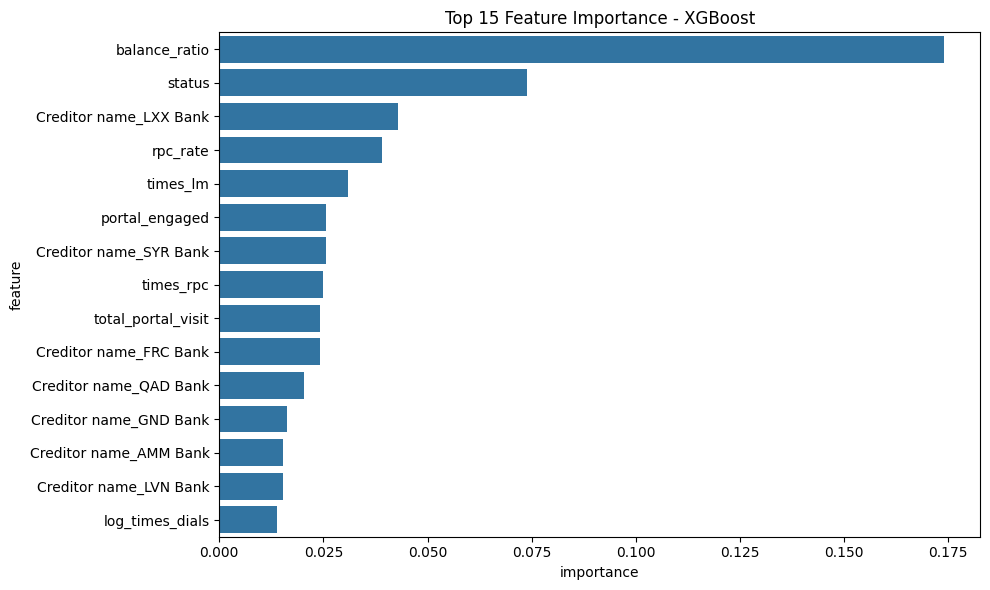

In [13]:
# Create Feature Importance DataFrame

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_smote_model.feature_importances_
})

# Sort descending
importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

# Display top features
display(importance_df.head(20))

# Plot Top Features

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='importance',
    y='feature'
)

plt.title("Top 15 Feature Importance - XGBoost")

plt.tight_layout()

plt.show()